# Total in 3 phases

- First Phase = Manually Preparing and checking everything for project. Just an idea (8 steps)
- Second phase = Adaptive Loop (REAL CORE)
- 3rd Phase = Final implementation of everything according to Project Proposal

# Phase 1 

## 1. Install Dependencies

In [17]:
!pip install sdv

   ---------------------------------------- 0.0/14.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.7 MB ? eta -:--:--
   -----------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiobotocore 2.19.0 requires botocore<1.36.4,>=1.36.0, but you have botocore 1.42.77 which is incompatible.
s3fs 2025.3.2 requires fsspec==2025.3.2.*, but you have fsspec 2026.1.0 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Loading Dataset

In [2]:
import pandas as pd

df = pd.read_csv('dataset\creditcard.csv')

print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Check Imbalance

In [3]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


<Axes: xlabel='Class', ylabel='count'>

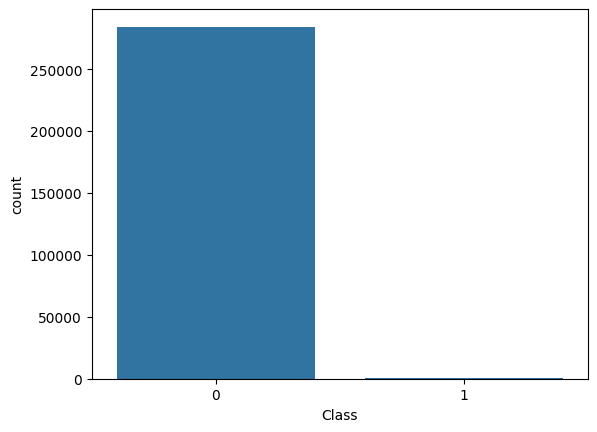

In [4]:
import seaborn as sns
sns.countplot(x='Class', data=df)

## 4. Train Base Model

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
X = df.drop('Class', axis=1)
y = df['Class']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
model = RandomForestClassifier(n_estimators=10, random_state=42)
model.fit(X_train, y_train)

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
y_pred = model.predict(X_test)

In [10]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.72      0.83        98

    accuracy                           1.00     56962
   macro avg       0.99      0.86      0.92     56962
weighted avg       1.00      1.00      1.00     56962

[[56862     2]
 [   27    71]]


👉 Pay attention to:
Fraud recall (will be bad)
False negatives (important)

## 5. Error Analysis (imp)

In [11]:
import numpy as np

In [12]:
# Get misclassified fraud cases
errors = X_test[(y_test == 1) & (y_pred == 0)]

In [13]:
print("Misclassified fraud cases:", errors.shape)

Misclassified fraud cases: (27, 30)


👉 This is your target zone.

## 6. Synthetic Data Generation (SDV)

In [18]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

In [19]:
# Filter data (Train only on fraud class)

train_df = pd.concat([X_train, y_train], axis=1)
fraud_data = train_df[train_df['Class'] == 1]

In [20]:
# Detect metadata from your dataframe
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(fraud_data)

In [21]:
# Initialize the model with the metadata and parameters
model_sdv = CTGANSynthesizer(metadata, epochs=5)

C:\Users\Engr Mujeeb Akbar\anaconda3\Lib\site-packages\sdv\single_table\base.py:178: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

C:\Users\Engr Mujeeb Akbar\anaconda3\Lib\site-packages\sdv\single_table\base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



In [22]:
# Fit the model to fraud data
model_sdv.fit(fraud_data)

In [23]:
# Generate synthetic data
synthetic_fraud = model_sdv.sample(num_rows=len(fraud_data))     # The parameter is now explicitly named 'num_rows'

In [24]:
print(synthetic_fraud.head())

       Time         V1         V2        V3         V4         V5        V6  \
0   32455.0 -16.059392   1.034658 -9.601351   6.131808  -6.804321 -3.025029   
1   29968.0  -1.240542  12.214477  2.250210   4.633775  -3.784619 -4.528017   
2   77815.0  -8.827703  -1.481014 -8.794455  10.451413 -10.776565 -0.184087   
3  119605.0 -14.966911   1.091438  2.250210   5.910457  -0.898225 -5.934519   
4  107476.0 -18.625493   3.350149  2.250210   5.917138  -4.010721  0.992357   

          V7         V8        V9  ...        V21       V22       V23  \
0 -31.886795   2.250521  0.681274  ...  -0.948365 -0.148650  0.717400   
1  -8.460742  12.845176  1.496509  ...  11.850852  8.316275 -5.932139   
2 -28.006004  -0.236164 -1.735990  ...  -5.900746  0.134068  0.349767   
3 -23.908063  -2.539156 -0.966625  ...  24.669034 -0.053372  1.584126   
4 -16.705273  -0.563639 -5.583051  ...  27.202839 -0.214833 -0.588676   

        V24       V25       V26       V27       V28  Amount  Class  
0 -0.969447 -0.46

## 7. Augment Data

In [25]:
augmented_train_df = pd.concat([train_df, synthetic_fraud], ignore_index=True)

In [26]:
X_train_aug = augmented_train_df.drop('Class', axis=1)
y_train_aug = augmented_train_df['Class']

## 8. Retrain Model

In [59]:
# Don't train-test-split again. We are cheching for improvement and if we use train-test-split it will be again from scratch

In [28]:
model.fit(X_train_aug, y_train_aug)
y_pred = model.predict(X_test)

In [29]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962

[[56862     2]
 [   24    74]]


# NEXT PHASE (Phase 2) = Adaptive Loop (REAL CORE)

## STEP 1 - Predict on TRAIN set (NOT test)

In [41]:
train_pred = model.predict(X_train_aug)

C:\Users\Engr Mujeeb Akbar\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning:

X has feature names, but RandomForestClassifier was fitted without feature names



In [42]:
train_pred

array([0, 0, 0, ..., 1, 1, 1], shape=(228239,))

## STEP 2 - Extract FALSE NEGATIVES (MOST IMPORTANT)

In [43]:
fn_mask = (y_train_aug == 1) & (train_pred == 0)

X_fn = X_train_aug[fn_mask]
y_fn = y_train_aug[fn_mask]

print("False Negatives:", len(X_fn))

False Negatives: 16


## STEP 3 - Convert FN data into DataFrame (for SDV)

In [44]:
df_fn = pd.DataFrame(X_fn)
df_fn["target"] = y_fn

## STEP 4 - Train Synthetic Data Generator (SDV)

In [45]:
from sdv.single_table import GaussianCopulaSynthesizer

In [46]:
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_fn)

synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(df_fn)

C:\Users\Engr Mujeeb Akbar\anaconda3\Lib\site-packages\sdv\single_table\base.py:178: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

C:\Users\Engr Mujeeb Akbar\anaconda3\Lib\site-packages\sdv\single_table\base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



## STEP 5 - Generate synthetic “hard fraud samples”

In [47]:
synthetic = synthesizer.sample(num_rows=len(df_fn))

## STEP 6 - Split synthetic data

In [48]:
X_syn = synthetic.drop(columns=["target"])
y_syn = synthetic["target"]

## STEP 7 - Augmenting training data (imp)

In [49]:
X_train_new = np.vstack([X_train_aug, X_syn])
y_train_new = np.hstack([y_train_aug, y_syn])

## STEP 8 - Retrain model (NEW ITERATION)

In [50]:
model.fit(X_train_new, y_train_new)

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## STEP 9 - Evaluate again (ONLY TEST SET)

In [51]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.73      0.84        98

    accuracy                           1.00     56962
   macro avg       0.99      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

[[56862     2]
 [   26    72]]


C:\Users\Engr Mujeeb Akbar\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning:

X has feature names, but RandomForestClassifier was fitted without feature names



## STEP 10 - Repeat (manual loop first)

Now just repeat:

- train predictions
- extract FN
- generate synthetic
- retrain
- evaluate

Run it 2–3 times manually first.

### Running the last 9 steps once again.

# FINAL IMPLEMENTATION (3rd phase)

## STEP 1 - Create tracking table

In [52]:
history = pd.DataFrame(columns=[
    "iteration", "precision", "recall", "f1", "false_negatives", "false_positives"
])

## STEP 2 - Create evaluation function

In [53]:
def evaluate_model(model, X_test, y_test, iteration):
    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    precision = report["1"]["precision"]
    recall = report["1"]["recall"]
    f1 = report["1"]["f1-score"]

    fn = cm[1][0]
    fp = cm[0][1]

    return precision, recall, f1, fn, fp

## STEP 3 - Create ONE adaptive iteration function

In [54]:
def adaptive_iteration(model, X_train, y_train):

    # Predict on training data
    train_pred = model.predict(X_train)

    # Extract False Negatives (hard fraud)
    fn_mask = (y_train == 1) & (train_pred == 0)

    X_fn = X_train[fn_mask]
    y_fn = y_train[fn_mask]

    print("FN samples:", len(X_fn))

    if len(X_fn) < 10:
        print("Too few FN samples - stopping")
        return X_train, y_train, False

    # Prepare dataframe for SDV
    df_fn = pd.DataFrame(X_fn)
    df_fn["target"] = y_fn

    # Train SDV
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(df_fn)

    synth = GaussianCopulaSynthesizer(metadata)
    synth.fit(df_fn)

    # Generate synthetic samples
    synthetic = synth.sample(len(df_fn))

    X_syn = synthetic.drop(columns=["target"])
    y_syn = synthetic["target"]

    # Augment training data
    X_new = np.vstack([X_train, X_syn])
    y_new = np.hstack([y_train, y_syn])

    # Retrain
    model.fit(X_new, y_new)

    return X_new, y_new, True

## STEP 4 - FULL AUTOMATED LOOP

In [55]:
max_iterations = 5
prev_fn = 9999

for i in range(max_iterations):

    print(f"\n=== Iteration {i+1} ===")

    # Run adaptive step
    X_train, y_train, continue_flag = adaptive_iteration(model, X_train, y_train)

    if not continue_flag:
        break

    # Evaluate on TEST SET (ALWAYS SAME)
    precision, recall, f1, fn, fp = evaluate_model(model, X_test, y_test, i)

    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"FN: {fn}, FP: {fp}")

    # Save history
    history.loc[i] = [i+1, precision, recall, f1, fn, fp]

    # 🔥 STOPPING CONDITION
    if fn >= prev_fn:
        print("No improvement — stopping loop")
        break

    prev_fn = fn


=== Iteration 1 ===


C:\Users\Engr Mujeeb Akbar\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning:

X has feature names, but RandomForestClassifier was fitted without feature names



FN samples: 16


C:\Users\Engr Mujeeb Akbar\anaconda3\Lib\site-packages\sdv\single_table\base.py:178: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

C:\Users\Engr Mujeeb Akbar\anaconda3\Lib\site-packages\sdv\single_table\base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.

C:\Users\Engr Mujeeb Akbar\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning:

X has feature names, but RandomForestClassifier was fitted without feature names



Precision: 0.9726027397260274
Recall: 0.7244897959183674
FN: 27, FP: 2

=== Iteration 2 ===
FN samples: 19


C:\Users\Engr Mujeeb Akbar\anaconda3\Lib\site-packages\sdv\single_table\base.py:178: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

C:\Users\Engr Mujeeb Akbar\anaconda3\Lib\site-packages\sdv\single_table\base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.

C:\Users\Engr Mujeeb Akbar\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning:

X has feature names, but RandomForestClassifier was fitted without feature names



Precision: 0.972972972972973
Recall: 0.7346938775510204
FN: 26, FP: 2

=== Iteration 3 ===
FN samples: 18


C:\Users\Engr Mujeeb Akbar\anaconda3\Lib\site-packages\sdv\single_table\base.py:178: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

C:\Users\Engr Mujeeb Akbar\anaconda3\Lib\site-packages\sdv\single_table\base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.

C:\Users\Engr Mujeeb Akbar\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning:

X has feature names, but RandomForestClassifier was fitted without feature names



Precision: 0.9733333333333334
Recall: 0.7448979591836735
FN: 25, FP: 2

=== Iteration 4 ===
FN samples: 17


C:\Users\Engr Mujeeb Akbar\anaconda3\Lib\site-packages\sdv\single_table\base.py:178: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

C:\Users\Engr Mujeeb Akbar\anaconda3\Lib\site-packages\sdv\single_table\base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



Precision: 0.9733333333333334
Recall: 0.7448979591836735
FN: 25, FP: 2
No improvement — stopping loop


C:\Users\Engr Mujeeb Akbar\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning:

X has feature names, but RandomForestClassifier was fitted without feature names



## STEP 5 - Showing results

In [56]:
print("\nFinal Results:")
print(history)


Final Results:
   iteration  precision    recall        f1  false_negatives  false_positives
0        1.0   0.972603  0.724490  0.830409             27.0              2.0
1        2.0   0.972973  0.734694  0.837209             26.0              2.0
2        3.0   0.973333  0.744898  0.843931             25.0              2.0
3        4.0   0.973333  0.744898  0.843931             25.0              2.0


## STEP 6 - Saving model and results

In [57]:
import joblib

joblib.dump(model, "final_model.pkl")
history.to_csv("training_history.csv", index=False)

In [61]:
joblib.dump(X_train_aug.columns.tolist(), "features.pkl")

['features.pkl']

## STEP 7 - Ploting

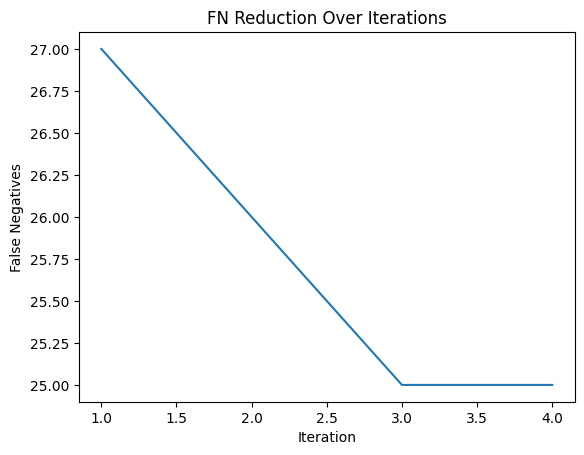

In [58]:
import matplotlib.pyplot as plt

plt.plot(history["iteration"], history["false_negatives"])
plt.xlabel("Iteration")
plt.ylabel("False Negatives")
plt.title("FN Reduction Over Iterations")
plt.show()